![](02_agentic_supervisor%20-%20Jupyter%20Notebook_files/logo_datascientest__-_Y.png)

* * *

#  Systèmes Agentiques ¶

##  Système multi-agents avec un Supervisor¶

* * *

> Dans l’exercice précédent, nous avons étudié une approche de planification inspirée de **REWOO** (_Reasoning Without Observations_).
> 
> Le principe était de : 
> 
>   *     1. Définir un plan avec plusieurs étapes et leurs dépendances.
>   *     2. Exécuter chaque étape séparément par des agents : l'agent n'utilise qu'un contexte limité pour traiter sa tâche.
>   *     3. Utiliser tous ces résultats pour produire une réponse finale.
> 
![](02_agentic_supervisor%20-%20Jupyter%20Notebook_files/mas_agent_rewoo__-_Y.png)
> 
> Cependant, cette approche implique que le plan est principalement défini au départ. Si les résultats intermédiaires changent la nature du problème, il peut être utile de réadapter la stratégie de résolution au fur et à mesure.

## Supervisor¶

> Une autre façon d’aborder le problème consiste à utiliser un **superviseur**.
> 
> Dans cette architecture, le superviseur joue le rôle d’un agent central chargé de décider comment traiter la demande utilisateur. Il peut :
> 
>   * **Répondre directement** lorsque la question est simple.
> 
>   * **Définir une stratégie** de résolution lorsque la demande est plus complexe.
> 
>   * **Déléguer** certaines sous-tâches à des agents spécialisés.
> 
>   * **Réadapter la stratégie** en fonction des résultats intermédiaires.
> 
> 

> 
> L’intérêt principal est donc de **rendre l’orchestration plus dynamique**. Contrairement à une approche où tout le plan est défini au départ, le superviseur peut choisir progressivement les prochaines actions à effectuer.
> 
> Cette approche devient particulièrement utile lorsque l’agent unique commence à atteindre certaines limites :
> 
>   * **Trop d’outils à disposition** : l’agent peut avoir du mal à choisir le bon outil, confondre certains usages ou avoir besoin d’un prompt système de plus en plus long pour gérer tous les cas particuliers.
> 
>   * **Beaucoup de contexte à traiter** : certaines tâches nécessitent de manipuler de nombreuses informations intermédiaires, ce qui peut rapidement augmenter le nombre de tokens et rendre le raisonnement moins fiable.
> 
>   * **Plusieurs sources ou visions à croiser** : un même problème peut demander à la fois une analyse de données structurées, une recherche textuelle, des calculs et une synthèse. Un agent unique peut alors se perdre dans les informations disponibles ou donner trop d’importance à une seule partie du problème.
> 
> 

> 
> Dans ces situations, un **système multi-agents permet de répartir le travail**. Chaque agent peut être spécialisé sur une partie du problème, avec ses propres outils et son propre contexte. Le **superviseur conserve alors une vision globale** de la tâche et coordonne les agents selon les besoins.

## Use case¶

> Dans cet exercice, nous allons construire un système capable d’analyser des communes françaises à partir de plusieurs sources d’information.
> 
> Le système pourra interroger des données structurées sur les communes, récupérer du contexte depuis Wikipédia, puis répondre à des questions permettant de mieux comparer les territoires français.
> 
> Par exemple :
> 
>   * Quelles villes moyennes semblent dynamiques d’après les données disponibles ?
> 
>   * Compare Rennes, Nantes et Montpellier sur leurs indicateurs territoriaux.
> 
>   * Trouve quelques communes avec une population en croissance et enrichis les plus pertinentes avec du contexte Wikipédia.
> 
> 

> 
> Pour cela, nous utiliserons quatre outils préconstruits :
> 
>   * `get_city_profile` : récupérer le profil territorial d’une commune précise ;
> 
>   * `query_city_database` : interroger la base de données des communes avec une requête SQL ;
> 
>   * `wikipedia` : rechercher des informations générales sur une commune ;
> 
>   * `python_repl` : exécuter du code Python pour effectuer des calculs ou manipuler des résultats.
> 
> 


  * Exécuter la cellule suivante afin de définir l'outil `get_city_profile`.


In [1]:
# ── Sanity check environnement local GPU ──────────────────────────────────
import platform, torch

print(f"Python       : {platform.python_version()}")
print(f"OS           : {platform.system()}")
print(f"CUDA dispo   : {torch.cuda.is_available()}  |  CUDA runtime : {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU          : {torch.cuda.get_device_name(0)}")
    print(f"Compute cap  : {torch.cuda.get_device_capability(0)}")
    x = torch.ones(3, 3).cuda()
    print(f"Test tenseur : OK {x.shape} sur {x.device}")
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"device       : {device}")


Python       : 3.10.12
OS           : Linux
CUDA dispo   : True  |  CUDA runtime : 12.8
GPU          : NVIDIA GeForce RTX 5070
Compute cap  : (12, 0)
Test tenseur : OK torch.Size([3, 3]) sur cuda:0
device       : cuda


In [2]:
# ── Configuration LLM ─────────────────────────────────────────────────────
import os
from dotenv import load_dotenv, find_dotenv

# Charge LIORA_API_KEY (et autres clés) depuis .env — recherche vers la racine
_dotenv_path = find_dotenv()
if _dotenv_path:
    load_dotenv(_dotenv_path, override=False)
    print(f"✓ .env chargé : {_dotenv_path}")
else:
    print("⚠ .env introuvable — vérifier le répertoire de travail")

def build_llm():
    """Liora gateway (priorité) → Ollama local (fallback)."""
    if os.environ.get("LIORA_API_KEY"):
        from langchain_openai import ChatOpenAI
        print("✓ LLM : Liora gateway → gpt-4o-mini")
        return ChatOpenAI(
            model="gpt-4o-mini",
            temperature=0,
            api_key=os.environ["LIORA_API_KEY"],
            base_url="https://ai-gateway.liora.tech/",
        )
    # Fallback GPU locale — prérequis : ollama serve dans un terminal
    from langchain_ollama import ChatOllama
    print("⚠ LLM : Ollama llama3.1:8b (fallback local — LIORA_API_KEY absent)")
    return ChatOllama(model="llama3.1:8b", temperature=0)

llm = build_llm()


✓ .env chargé : /home/tchumi/NLP_cours/.env
✓ LLM : Liora gateway → gpt-4o-mini


In [3]:
import pandas as pd

pd.set_option("display.max_columns", None)

city_indicators = pd.read_csv(
    "base_cc_comparateur.csv",
    sep=";",
    dtype={"CODGEO": str}
)

city_names = pd.read_csv(
    "v_commune_2026.csv",
    sep=",",
    dtype={"COM": str, "DEP": str}
)

city_profiles = city_indicators.merge(
    city_names,
    left_on="CODGEO",
    right_on="COM",
    how="left"
)

city_profiles = city_profiles[
    [
        "CODGEO",
        "LIBELLE",
        "DEP",
        "REG",
        "P22_POP",
        "P16_POP",
        "SUPERF",
        "P22_MEN",
        "P22_LOG",
        "P22_RP",
        "P22_LOGVAC",
        "MED21",
        "P22_EMPLT",
        "P22_POP1564",
        "P22_CHOM1564",
        "P22_ACT1564",
        "ETTOT24"
    ]
]

city_profiles = city_profiles.rename(columns={
    "CODGEO": "city_code",
    "LIBELLE": "city_name",
    "DEP": "department_code",
    "REG": "region_code",
    "P22_POP": "population_2022",
    "P16_POP": "population_2016",
    "SUPERF": "surface_km2",
    "P22_MEN": "households_2022",
    "P22_LOG": "housing_units_2022",
    "P22_RP": "main_residences_2022",
    "P22_LOGVAC": "vacant_housing_2022",
    "MED21": "median_income_2021",
    "P22_EMPLT": "jobs_2022",
    "P22_POP1564": "population_15_64_2022",
    "P22_CHOM1564": "unemployed_15_64_2022",
    "P22_ACT1564": "active_15_64_2022",
    "ETTOT24": "establishments_2024"
})

from difflib import get_close_matches
from langchain_core.tools import tool

@tool
def get_city_profile(city: str) -> dict:
    """
    Récupère le profil territorial d'une commune française.

    Args:
        city: Nom de la commune à rechercher, par exemple "Rennes", "Nantes" ou "Strasbourg".

    Returns:
        Un dictionnaire contenant les principales informations disponibles sur la commune :
        code commune, nom, département, région, population, superficie, emploi,
        chômage, revenu médian et nombre d'établissements.

        Si aucune commune ne correspond exactement au nom saisi, la fonction tente
        de retrouver la commune la plus proche.
    """
    city = city.strip().lower()

    city_profiles_copy = city_profiles.copy()
    city_profiles_copy["city_name_normalized"] = (
        city_profiles_copy["city_name"]
        .str.lower()
        .str.strip()
    )

    matching_rows = city_profiles_copy[
        city_profiles_copy["city_name_normalized"] == city
    ]

    if matching_rows.empty:
        city_names = city_profiles_copy["city_name_normalized"].dropna().unique()

        closest_matches = get_close_matches(
            city,
            city_names,
            n=1,
            cutoff=0.75
        )

        if not closest_matches:
            return {
                "error": f"Aucune commune trouvée pour '{city}'."
            }

        matching_rows = city_profiles_copy[
            city_profiles_copy["city_name_normalized"] == closest_matches[0]
        ]

    city_profile = matching_rows.iloc[0].drop("city_name_normalized")

    return city_profile.to_dict()


get_city_profile.invoke("Paris")


{'city_code': '75056',
 'city_name': 'Paris',
 'department_code': '75',
 'region_code': 11.0,
 'population_2022': 2113705.0,
 'population_2016': 2190327.0,
 'surface_km2': 105.4,
 'households_2022': 1125472.67901453,
 'housing_units_2022': 1399122.25789351,
 'main_residences_2022': 1125472.67901453,
 'vacant_housing_2022': 136956.663839098,
 'median_income_2021': '29730',
 'jobs_2022': 1905855.96267225,
 'population_15_64_2022': 1469487.9716853,
 'unemployed_15_64_2022': 121919.245187499,
 'active_15_64_2022': 1156048.4837653,
 'establishments_2024': 188002.0}

  * Exécuter la cellule suivante afin de définir l'outil `query_city_database`.


In [4]:
import sqlite3
import pandas as pd
import tempfile
import os
from langchain_core.tools import tool

DB_PATH = os.path.join(tempfile.gettempdir(), "city_profiles.sqlite")

# Création / écriture initiale
with sqlite3.connect(DB_PATH) as connection:
    city_profiles.to_sql(
        "city_profiles",
        connection,
        index=False,
        if_exists="replace"
    )


@tool
def query_city_database(query: str) -> list[dict] | dict:
    """
    Exécute une requête SQL SELECT en lecture seule sur la table city_profiles.
    Le résultat est plafonné à 50 lignes pour éviter de saturer le contexte du LLM.
    """
    MAX_ROWS = 50

    cleaned_query = query.strip().lower()

    if not cleaned_query.startswith("select"):
        return {"error": "Seules les requêtes SELECT sont autorisées."}

    try:
        # Ouverture read-only
        read_only_uri = f"file:{DB_PATH}?mode=ro"

        with sqlite3.connect(read_only_uri, uri=True) as connection:
            result = pd.read_sql_query(query, connection)

        total_rows = len(result)
        truncated = total_rows > MAX_ROWS
        result = result.head(MAX_ROWS)

        records = result.to_dict(orient="records")

        if truncated:
            return {
                "warning": (
                    f"Résultat tronqué à {MAX_ROWS} lignes sur {total_rows} au total. "
                    "Ajoute une clause LIMIT ou affine les filtres (WHERE) pour une requête plus précise."
                ),
                "rows": records,
            }

        return records

    except Exception as error:
        return {
            "error": str(error),
            "query": query,
        }
    
query_city_database.invoke({
    "query": """
        SELECT city_name, population_2022, surface_km2
        FROM city_profiles
        WHERE department_code = '35'
        ORDER BY population_2022 DESC
        LIMIT 5
    """
})


[{'city_name': 'Rennes', 'population_2022': 227830.0, 'surface_km2': 50.39},
 {'city_name': 'Saint-Malo', 'population_2022': 47255.0, 'surface_km2': 36.58},
 {'city_name': 'Fougères', 'population_2022': 20602.0, 'surface_km2': 10.46},
 {'city_name': 'Bruz', 'population_2022': 19667.0, 'surface_km2': 29.95},
 {'city_name': 'Vitré', 'population_2022': 18892.0, 'surface_km2': 37.03}]

  * Exécuter la cellule suivante afin de définir l'outil `wikipedia`.


In [5]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
import wikipedia

wikipedia.set_lang("fr")

wikipedia.wikipedia.USER_AGENT = (
    "my-langchain-app/0.1 "
    "(https://example.com; your-email@example.com)"
)


wikipedia = WikipediaQueryRun(
    api_wrapper=WikipediaAPIWrapper(lang="fr", doc_content_chars_max=10000)
)

wikipedia.invoke("Lyon")


"Page: Lyon\nSummary: Lyon est une commune française située dans le centre-est de la France, au confluent du Rhône et de la Saône. Elle est, en 2023, la troisième commune de France la plus peuplée, derrière Marseille et la capitale Paris. Elle est également le chef-lieu de la circonscription départementale du Rhône et de la région Auvergne-Rhône-Alpes (ou Rhône-Alpes avant 2015).\nLa ville a une situation de carrefour géographique du pays, au nord du couloir rhodanien qui court de Lyon à Marseille. Située entre le Massif central à l'ouest, le massif alpin et le massif du Jura à l'est, la ville de Lyon occupe une position stratégique dans la circulation nord-sud en Europe. Ancienne capitale des Gaules du temps de l'Empire romain, elle est le siège d'un archevêché dont le titulaire porte le titre de primat des Gaules. Lyon devint une ville très commerçante et une place financière de premier ordre à la Renaissance. Sa prospérité économique est portée aussi à cette époque par la soierie et

  * Exécuter la cellule suivante afin de définir l'outil `python_repl`.


In [6]:
from langchain_experimental.tools import PythonREPLTool

python_repl = PythonREPLTool()
python_repl.invoke("print(1+1)")


Python REPL can execute arbitrary code. Use with caution.


'2\n'

> Nous allons commencer par créer un **agent unique** capable d’utiliser tous les outils disponibles.
> 
> Nous testerons ensuite ses limites sur des requêtes plus complexes, avant de mettre en place un **système multi-agents avec superviseur** pour mieux répartir les tâches et mieux gérer le contexte.

* * *

##  Implémentation d'un agent et ses limites ¶

* * *

> Nous allons commencer par créer un agent unique capable d’utiliser l’ensemble des outils définis précédemment.

  * Instancier un agent LangChain capable d’utiliser nos quatre outils.

  * Tester ensuite l’agent sur une première question simple. Afficher pour chaque requête user le nombre total de tokens ainsi que le coût.


In [7]:
from langchain_openai import ChatOpenAI
from langgraph.checkpoint.memory import InMemorySaver
from langchain.agents import create_agent
from langchain_community.callbacks import get_openai_callback
from uuid import uuid4
import os
# Choose the provider
# os.environ["OPENAI_API_BASE"] = "https://api.groq.com/openai/v1" # If you use Groq
# os.environ["OPENAI_API_BASE"] = "https://api.openai.com/v1"      # If you use OpenAI
# os.environ["OPENAI_API_BASE"] = "https://ai-gateway.liora.tech/" # If you use the Liora GateWay

# Insert the api_key and model_name
# api_key = "my key"
# model_name = "gpt-4o-mini"
# Insérer voter code ici


In [8]:
from IPython.display import display, Markdown


# llm = ChatOpenAI(model_name=model_name, temperature=0, api_key=api_key)

tools = [
    get_city_profile,
    query_city_database,
    wikipedia,
    python_repl
]

memory = InMemorySaver()

agent = create_agent(
    model=llm,
    tools=tools,
    checkpointer=memory,
    system_prompt="""
    Tu es un assistant spécialisé dans l'analyse de communes françaises.
    
    Tu peux utiliser les outils à ta disposition pour récupérer des données chiffrées,
    obtenir du contexte général sur une commune, ou réaliser des calculs intermédiaires.
    
    Lorsque tu utilises des données numériques, explique brièvement les calculs réalisés.
    """
)

thread_id = f"analyse_commune_{uuid4().hex}"

config = {
    "configurable": {
        "thread_id": thread_id
    },
    "recursion_limit": 5
}

with get_openai_callback() as cb:
    # Insérer votre code ici
    result = agent.invoke(
    {
        "messages": [
            {
                "role": "user",
                "content": "Tu peux me faire un état des lieux de Paris ?"
            }
        ]
    },
    config=config
    )
    
print(f"Cost in dollars : {cb.total_cost}")
print(f"Total number token : {cb.total_tokens}")

display(Markdown(result["messages"][-1].content))


Cost in dollars : 0.00035955
Total number token : 1377


Voici un état des lieux de Paris :

- **Code commune** : 75056
- **Nom** : Paris
- **Code département** : 75
- **Région** : Île-de-France
- **Population (2022)** : 2 113 705 habitants
- **Population (2016)** : 2 190 327 habitants (une diminution de 76 622 habitants en six ans)
- **Superficie** : 105,4 km²
- **Nombre de ménages (2022)** : environ 1 125 473
- **Unités de logement (2022)** : environ 1 399 122
- **Résidences principales (2022)** : environ 1 125 473
- **Logements vacants (2022)** : environ 136 957
- **Revenu médian (2021)** : 29 730 € par an
- **Emplois (2022)** : environ 1 905 856
- **Population active (15-64 ans, 2022)** : environ 1 469 488
- **Chômeurs (15-64 ans, 2022)** : environ 121 919
- **Établissements (2024)** : environ 188 002

Ces données montrent une ville dynamique avec une population importante, mais également des défis en matière de logement et d'emploi. La diminution de la population entre 2016 et 2022 pourrait être un point d'intérêt pour des analyses plus approfondies.

> L’agent fonctionne correctement sur une requête simple comme l’analyse d’une seule commune.
> 
> Nous allons maintenant tester une demande plus complexe. L’objectif est de demander à l’agent de rechercher plusieurs communes candidates, puis d’enrichir chacune d’elles avec du contexte Wikipédia.

  * Tester maintenant l’agent sur la requête suivante.


In [19]:
complex_query = """
Je cherche une commune d'Île-de-France où il pourrait être intéressant de vivre.

Je ne veux pas forcément une grande ville connue, mais plutôt une commune avec un bon équilibre entre dynamisme, cadre de vie, accessibilité et intérêt culturel ou historique.

Analyse les communes possibles, compare-les, puis propose-moi celles qui semblent les plus pertinentes.
"""

# Insérer voter code ici


In [20]:
from langgraph.errors import GraphRecursionError
from langchain_core.messages import HumanMessage, SystemMessage, AIMessage, ToolMessage

complex_query = """
Je cherche une commune d'Île-de-France où il pourrait être intéressant de vivre.

Je ne veux pas forcément une grande ville connue, mais plutôt une commune avec un bon équilibre entre dynamisme, cadre de vie, accessibilité et intérêt culturel ou historique.

Analyse les communes possibles, compare-les, puis propose-moi celles qui semblent les plus pertinentes.
"""



thread_id = f"analyse_commune_{uuid4().hex}"

config = {
    "configurable": {"thread_id": thread_id},
    "recursion_limit": 5
}

def clean_messages_for_final_answer(messages):
    cleaned = []

    for msg in messages:
        # On enlève les ToolMessage
        if isinstance(msg, ToolMessage):
            continue

        # On enlève les AIMessage qui contiennent des tool_calls
        if isinstance(msg, AIMessage) and getattr(msg, "tool_calls", None):
            if msg.content:
                cleaned.append(AIMessage(content=msg.content))
            continue

        cleaned.append(msg)

    return cleaned


with get_openai_callback() as cb:
    try:
        result = agent.invoke(
            {
                "messages": [
                    HumanMessage(content=complex_query)
                ]
            },
            config=config
        )

    except GraphRecursionError:
        print("Error recursion_limit reached")
        state = agent.get_state(config)
        previous_messages = state.values["messages"]

        final_messages = [
            SystemMessage(content="""
Tu dois répondre directement à la question initiale.

Tu n'as plus le droit d'appeler d'outils.
Utilise uniquement les informations déjà présentes dans la conversation.
Si certaines données manquent, indique-le clairement.
Produis une réponse structurée et exploitable.
"""),
            *clean_messages_for_final_answer(previous_messages),
            HumanMessage(content="Réponds maintenant à la question initiale, sans utiliser d'outils.")
        ]

        final_answer = llm.invoke(final_messages)

        result = {
            "messages": [*previous_messages, final_answer]
        }

print(f"Cost in dollars : {cb.total_cost}")
print(f"Total number token : {cb.total_tokens}")

display(Markdown(result["messages"][-1].content))


Error recursion_limit reached
Cost in dollars : 0.0007369499999999999
Total number token : 2681


Voici une sélection de communes d'Île-de-France qui pourraient correspondre à vos critères d'un bon équilibre entre dynamisme, cadre de vie, accessibilité et intérêt culturel ou historique :

### 1. **Sceaux (Hauts-de-Seine)**
   - **Dynamisme** : Ville dynamique avec des commerces et des activités culturelles.
   - **Cadre de vie** : Parc de Sceaux, un grand espace vert, et un cadre résidentiel agréable.
   - **Accessibilité** : Bien desservie par le RER B, facilitant l'accès à Paris.
   - **Intérêt culturel** : Château de Sceaux et ses jardins, musée de l'Île-de-France.

### 2. **Saint-Germain-en-Laye (Yvelines)**
   - **Dynamisme** : Ville vivante avec de nombreux événements et activités.
   - **Cadre de vie** : Quartiers résidentiels, espaces verts et proximité de la forêt de Saint-Germain.
   - **Accessibilité** : RER A qui permet de rejoindre Paris rapidement.
   - **Intérêt culturel** : Château de Saint-Germain-en-Laye, musée des Antiquités nationales.

### 3. **Fontainebleau (Seine-et-Marne)**
   - **Dynamisme** : Ville attractive avec un bon nombre de commerces et d'activités.
   - **Cadre de vie** : Environnement naturel exceptionnel avec la forêt de Fontainebleau.
   - **Accessibilité** : Accès en train à Paris en environ 40 minutes.
   - **Intérêt culturel** : Château de Fontainebleau, classé au patrimoine mondial de l'UNESCO.

### 4. **Versailles (Yvelines)**
   - **Dynamisme** : Ville historique avec une vie culturelle riche.
   - **Cadre de vie** : Quartiers agréables, jardins et parcs.
   - **Accessibilité** : RER C et trains directs vers Paris.
   - **Intérêt culturel** : Château de Versailles et ses jardins, événements culturels fréquents.

### 5. **Maisons-Laffitte (Yvelines)**
   - **Dynamisme** : Ville calme mais avec une vie associative et culturelle active.
   - **Cadre de vie** : Environnement verdoyant, proche de la Seine.
   - **Accessibilité** : RER A, accès rapide à Paris.
   - **Intérêt culturel** : Château de Maisons-Laffitte, architecture du XVIIIe siècle.

### Conclusion
Ces communes offrent un bon compromis entre la vie urbaine et un cadre de vie agréable, tout en étant accessibles à Paris. Chacune a ses propres atouts culturels et historiques, ce qui peut enrichir votre expérience de vie. Il serait intéressant de visiter ces communes pour ressentir l'ambiance et voir laquelle vous attire le plus.

> Sur ce type de requête, l’agent unique peut rapidement atteindre ses limites.
> 
> Dans le meilleur des cas, il parvient à produire une réponse correcte, mais au prix d’un grand nombre d’appels outils et d’une consommation importante de tokens.
> 
> Dans le pire des cas, il se perd dans les résultats intermédiaires : il récupère trop d’informations, conserve trop de contexte, multiplie les recherches et finit par produire une réponse difficile à contrôler.
> 
> Ce problème vient du fait qu’un seul agent doit gérer en même temps la stratégie de recherche, les données structurées, les informations Wikipédia, les calculs intermédiaires et la synthèse finale.
> 
> Pour mieux contrôler ce type de tâche, on peut répartir le travail entre plusieurs agents spécialisés, coordonnés par un superviseur.

* * *

##  Supervisor ¶

* * *

> Le superviseur est un agent central qui reçoit la demande utilisateur, décide de la stratégie à suivre, puis choisit les agents spécialisés à appeler.
> 
> Chaque agent spécialisé dispose de ses propres outils et traite une partie limitée du problème. Il renvoie ensuite un résultat intermédiaire au superviseur, qui peut décider de continuer la recherche, d’appeler un autre agent ou de produire la réponse finale.
> 
> ![](02_agentic_supervisor%20-%20Jupyter%20Notebook_files/mas_superviser_structure__-_Y.png) **Figure** : Un superviseur coordonne plusieurs agents spécialisés, jusqu'à arriver à la réponse finale ([source](https://weaviate.io/assets/images/Multi_Agent_RAG_System-73e480f62a52e172a78a0ac344dcdcb5.png))
> 
> Dans notre cas d’usage, le superviseur pourra par exemple :
> 
>   * appeler un agent spécialisé dans les données structurées pour identifier des communes candidates.
> 
>   * appeler un agent spécialisé dans Wikipédia pour enrichir certaines communes avec du contexte textuel.
> 
>   * agréger les résultats pour produire une réponse finale plus synthétique.
> 
> 

> 
> Cette architecture permet de mieux contrôler le contexte : chaque agent ne manipule que les informations utiles à sa tâche, au lieu de faire porter toute la recherche à un seul agent.
> 
> Elle présente néanmoins des limites : 
> 
>   * **Goulot d’étranglement au niveau du superviseur** : toute la logique passe par un seul agent, ce qui peut entraîner des **délais** ou **points de défaillance** si le superviseur se trompe. Par exemple, dans un système de génération de code, un agent "générateur" doit d’abord passer par le superviseur pour que l’agent "relecture et test" puisse vérifier le code, ce qui augmente considérablement le contexte du superviseur, et ralentit le processus.
> 
>   * **Faible autonomie des agents** : les agents spécialisés restent **passifs** , n’interagissent pas entre eux, et attendent simplement les ordres du superviseur. Cela limite la **collaboration** entre agents, qui peut être **cruciale** pour certaines tâches complexes (débattre, etc).
> 
>   * **Coordination difficile** : plus il y a d’agents spécialisés, plus la logique de contrôle devient **difficile à maintenir** , surtout si les interactions sont nombreuses.
> 
> 


## Implémentation avec langchain¶

> Pour implémenter ce type d’architecture, nous allons utiliser la fonction **`create_supervisor`** de `langgraph_supervisor`.
> 
> Cette fonction permet d'**orchestrer** plusieurs agents spécialisés. Chaque agent possède ses propres outils, et le superviseur décide quel agent appeler selon la demande utilisateur.

  * Exécuter la cellule suivante qui présente le fonctionnement exact de la communication entre les agents.


In [21]:
from widget_create_supervisor_langgraph import show_supervisor_viz

show_supervisor_viz()


ModuleNotFoundError: No module named 'widget_create_supervisor_langgraph'

> Voici un exemple minimal avec deux agents : un agent spécialisé dans la recherche d’informations et un agent spécialisé dans les calculs.
>     
>     
>     from langchain_openai import ChatOpenAI
>     from langchain_core.tools import tool
>     from langgraph_supervisor import create_supervisor
>     from langchain.agents import create_agent
>     
>     model = ChatOpenAI(model="gpt-4o-mini")
>     
>     @tool
>     def add(a: float, b: float) -> float:
>         """Add two numbers."""
>         return a + b
>     
>     @tool
>     def multiply(a: float, b: float) -> float:
>         """Multiply two numbers."""
>         return a * b
>     
>     @tool
>     def web_search(query: str) -> str:
>         """Search the web for information."""
>         return (
>             "Here are the headcounts for each of the FAANG companies in 2024:\n"
>             "1. Meta: 67,317 employees.\n"
>             "2. Apple: 164,000 employees.\n"
>             "3. Amazon: 1,551,000 employees.\n"
>             "4. Netflix: 14,000 employees.\n"
>             "5. Alphabet: 181,269 employees."
>         )
>     
>     math_agent = create_agent(
>         model=model,
>         tools=[add, multiply],
>         name="math_expert",
>         system_prompt="You are a math expert. Always use one tool at a time."
>     )
>     
>     research_agent = create_agent(
>         model=model,
>         tools=[web_search],
>         name="research_expert",
>         system_prompt="You are a researcher. Do not do any math."
>     )
>     
>     workflow = create_supervisor(
>         [research_agent, math_agent],
>         model=model,
>         tools=[add, multiply, web_search], # Tools avaiblables to the supervisor
>         prompt=(
>             "You are a supervisor managing a research expert and a math expert. "
>             "For research questions, use research_expert. "
>             "For math questions, use math_expert."
>         )
>     )
>     
>     app = workflow.compile()
>     
>     result = app.invoke(
>         {
>             "messages": [
>                 {
>                     "role": "user",
>                     "content": "What is the combined headcount of the FAANG companies in 2024?"
>                 }
>             ]
>         }
>     )
>     

## Implémentation des agents spécialisés¶

> Nous allons maintenant créer deux agents spécialisés.
> 
>   * **`territory_expert`** : un agent spécialisé dans l’analyse des données structurées sur les communes françaises. Il pourra récupérer le profil d’une commune, interroger la base SQL et utiliser Python pour réaliser des calculs intermédiaires.
> 
>   * **`wikipedia_expert`** : un agent spécialisé dans la recherche d’informations textuelles sur Wikipédia. Il pourra enrichir l’analyse d’une commune avec du contexte historique, géographique, culturel ou touristique.
> 
> 

> 
> Chaque agent aura donc un rôle plus limité, avec moins d’outils à gérer et un contexte plus ciblé.

  * Créer un agent **`territory_expert`** avec les outils `get_city_profile`, `query_city_database` et `python_repl`.

  * Créer un agent **`wikipedia_expert`** avec l’outil `wikipedia`.

  * Définir un prompt clair pour chaque agent afin de préciser son rôle et les limites de son périmètre.


In [ ]:
# Insérer votre code ici


In [9]:
from langchain.agents import create_agent

territory_agent = create_agent(
    model=llm,
    tools=[
        get_city_profile,
        query_city_database,
        python_repl
    ],
    name="territory_expert",
    system_prompt="""
    Tu es un expert en analyse territoriale des communes françaises.

    Ton rôle est d'exploiter uniquement les données structurées disponibles sur les communes :
    population, surface, densité, revenu médian, emploi, chômage, logements,
    logements vacants, établissements, département et région.

    Outils disponibles :
    - get_city_profile : récupérer le profil d'une commune précise ;
    - query_city_database : interroger la base de données des communes avec SQL ;
    - python_repl : effectuer des calculs intermédiaires si nécessaire.

    Règles générales :
    - Utilise uniquement les données structurées disponibles dans les outils.
    - Ne cherche pas d'informations historiques, culturelles ou touristiques.
    - Ne fais pas de recherche Wikipédia.
    - Si une question demande de comparer plusieurs communes, utilise prioritairement query_city_database.
    - Si tu effectues un calcul, explique brièvement la formule utilisée.
    - Si une donnée est absente ou incertaine, indique-le clairement.

    Règles pour les demandes ouvertes du type "où vivre", "commune intéressante", "cadre de vie" :
    - Ne tente jamais d'analyser toutes les communes.
    - Commence par construire une présélection avec SQL.
    - Limite la présélection à 10 communes maximum.
    - Pour l'Île-de-France, filtre sur region = 'Île-de-France' ou l'équivalent exact présent dans la base.
    - Évite les très grandes communes si l'utilisateur demande une commune pas forcément connue.
    - Privilégie des communes avec :
      population intermédiaire,
      densité raisonnable,
      revenu médian plutôt favorable,
      chômage modéré,
      nombre d'établissements significatif,
      vacance des logements non excessive.
    - Retourne un tableau synthétique avec les colonnes disponibles les plus utiles.
    - Termine par une shortlist de 5 à 8 communes maximum à enrichir par wikipedia_expert.
    - Ne produis pas la recommandation finale : ton résultat sera complété par wikipedia_expert.

    Format de sortie attendu :
    1. Méthode de sélection en une phrase.
    2. Tableau des communes candidates.
    3. Shortlist finale pour enrichissement Wikipédia, 5 à 8 communes maximum.
    4. Limites des données.
    """
)


wikipedia_agent = create_agent(
    model=llm,
    tools=[
        wikipedia
    ],
    name="wikipedia_expert",
    system_prompt="""
    Tu es un expert en recherche d'informations générales sur les communes françaises.

    Ton rôle est d'utiliser Wikipédia pour récupérer du contexte qualitatif sur une ville :
    histoire, géographie, patrimoine, culture, tourisme, environnement,
    positionnement territorial ou éléments notables.

    Tu peux utiliser l'outil suivant :
    - wikipedia : pour rechercher des informations sur une commune ou un territoire.

    Règles importantes :
    - Ne fais pas d'analyse chiffrée avancée.
    - Ne cherche pas à calculer des indicateurs territoriaux.
    - Ne remplace pas les données structurées par des informations Wikipédia.
    - Concentre-toi sur le contexte qualitatif utile pour comprendre la commune.
    - Résume les informations de manière compacte.
    - Évite les longues descriptions encyclopédiques.
    - Si Wikipédia ne donne pas assez d'informations pertinentes, indique-le clairement.
    - Retourne une synthèse exploitable par un superviseur.

    Ton objectif est d'enrichir l'analyse d'une commune avec du contexte textuel.
    """
)


## Implémentation du superviseur¶

> Nous avons maintenant défini nos deux agents spécialisés. Il reste à créer un **superviseur** capable de coordonner ces agents selon la demande utilisateur.
> 
> Le superviseur devra décider s’il doit mobiliser l’agent spécialisé dans les données structurées, l’agent spécialisé dans Wikipédia, ou les deux.

Créer un workflow avec `create_supervisor` :

  * utiliser les agents `territory_agent` et `wikipedia_agent` ;

  * définir un prompt système indiquant clairement le rôle du superviseur ;

  * compiler le workflow dans une variable `app` ;

  * tester le système sur la même requête complexe que précédemment ;

  * afficher la réponse finale du superviseur.


In [10]:
from langgraph_supervisor import create_supervisor
# Insérer votre code ici


In [11]:
from langgraph_supervisor import create_supervisor
from langgraph.checkpoint.memory import InMemorySaver

workflow = create_supervisor(
    agents=[
        territory_agent,
        wikipedia_agent
    ],
    model=llm,
    tools=tools,
    parallel_tool_calls=True,
    output_mode="last_message",# "full_history",
    prompt="""
    Tu es un superviseur chargé de coordonner plusieurs agents spécialisés
    pour répondre à des questions sur les communes françaises.

    Tu disposes de deux agents :
    - territory_expert : spécialisé dans les données structurées sur les communes ;
    - wikipedia_expert : spécialisé dans les informations textuelles issues de Wikipédia.

    Ton rôle est de décider quel agent appeler selon la demande utilisateur,
    puis d'agréger les résultats de manière synthétique.

    Règles de routage :
    - Si la question est simple, ne demande pas beaucoup de contexte, essayes de répondre directement,
    - Si la question porte sur des indicateurs chiffrés, des comparaisons, des filtres ou des calculs,
      utilise territory_expert.
    - Si la question demande du contexte historique, géographique, culturel, touristique ou textuel,
      utilise wikipedia_expert.
    - Si la question nécessite à la fois des données structurées et du contexte qualitatif,
      appelle territory_expert et wikipedia_expert dans l'ordre le plus pertinent.

    Règles spécifiques pour les recherches Wikipédia :
    - N'envoie jamais plus de 5 communes à la fois à wikipedia_expert.
    - Si la demande implique plus de 5 communes nécessitant une analyse Wikipédia,
      découpe la liste en lots de 5 communes maximum.
    - Appelle wikipedia_expert une fois par lot.
    - Chaque appel à wikipedia_expert doit contenir uniquement les communes du lot concerné
      et une consigne claire sur les informations textuelles attendues.

    Exemples de découpage :
    - Pour 1 à 5 communes : un seul appel à wikipedia_expert.
    - Pour 6 à 10 communes : deux appels à wikipedia_expert.
    - Pour 11 à 15 communes : trois appels à wikipedia_expert.
    - Pour N communes : autant d'appels que nécessaire, avec 5 communes maximum par appel.

    Règles de qualité :
    - Ne demande pas à un agent de faire une tâche hors de son périmètre.
    - Si la demande est simple, tu peux répondre directement sans appeler inutilement les agents.
    - Si territory_expert fournit une liste de communes qui doit ensuite être enrichie avec du contexte Wikipédia,
      applique aussi la règle des lots de 5 communes maximum pour wikipedia_expert.
    - Ta réponse finale doit être claire, structurée et justifiée.
    """
)

checkpointer = InMemorySaver()
app = workflow.compile(checkpointer=checkpointer)


  * Afficher la graphe de notre architecture.


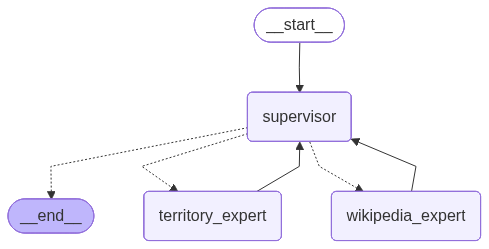

In [12]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))


  * Tester notre workflow sur la question complexe suivante.


In [13]:
complex_query = """
Je cherche une commune d'Île-de-France où il pourrait être intéressant de vivre.

Je ne veux pas forcément une grande ville connue, mais plutôt une commune avec un bon équilibre entre dynamisme, cadre de vie, accessibilité et intérêt culturel ou historique.

Analyse les communes possibles, compare-les, puis propose-moi celles qui semblent les plus pertinentes.
"""

# Insérer votre code ici


In [14]:
from pprint import pformat
from uuid import uuid4
from langchain_core.messages import AIMessage, ToolMessage
from langgraph.errors import GraphRecursionError

thread_id = f"analyse_commune_{uuid4().hex}"

config = {
    "configurable": {
        "thread_id": thread_id
    },
    "recursion_limit": 10
}

inputs = {
    "messages": [
        {
            "role": "user",
            "content": complex_query,
        }
    ]
}

events = []

with get_openai_callback() as cb:
    try:
        for part in app.stream(
            inputs,
            config=config,
            stream_mode="debug",
            subgraphs=True,
            version="v2",
        ):
            events.append(part)

            print("\n" + "=" * 100)
            print("TYPE:", part.get("type"))
            print("NS:", part.get("ns")) 
            print("-" * 100)
            print(pformat(part.get("data"), width=140, compact=False))

    except GraphRecursionError as e:
        print("\n" + "!" * 100)
        print("GRAPH RECURSION ERROR")
        print(e)

print(f"Cost in dollars : {cb.total_cost}")
print(f"Total number token : {cb.total_tokens}")



TYPE: debug
NS: ()
----------------------------------------------------------------------------------------------------
{'payload': {'config': {'configurable': {'checkpoint_id': '1f17bb4d-c26d-6668-bfff-99ef3c0dc638',
                                         'checkpoint_ns': '',
                                         'thread_id': 'analyse_commune_6dfb95000b60412db6219d828727411a'}},
             'metadata': {'parents': {}, 'source': 'input', 'step': -1},
             'next': ['__start__'],
             'parent_config': None,
             'tasks': [{'id': 'b583b073-4815-3957-e51c-c8232b93df72', 'interrupts': (), 'name': '__start__', 'state': None}],
             'values': {'messages': []}},
 'step': -1,
 'timestamp': '2026-07-09T16:40:14.306915+00:00',
 'type': 'checkpoint'}

TYPE: debug
NS: ()
----------------------------------------------------------------------------------------------------
{'payload': {'config': {'configurable': {'checkpoint_id': '1f17bb4d-c273-62ce-8000-186eb397

In [16]:
from pprint import pformat
from uuid import uuid4
from langchain_core.messages import AIMessage, ToolMessage
from langgraph.errors import GraphRecursionError
from IPython.display import display, Markdown

thread_id = f"analyse_commune_{uuid4().hex}"

config = {
    "configurable": {
        "thread_id": thread_id
    },
    "recursion_limit": 25
}

inputs = {
    "messages": [
        {
            "role": "user",
            "content": complex_query,
        }
    ]
}

with get_openai_callback() as cb:
    try:
        for part in app.stream(
            inputs,
            config=config,
            stream_mode="debug",
            subgraphs=True,
            version="v2",
        ):
            if part.get("type") != "task_result":
                continue

            payload = part["payload"]
            last_msg = payload["result"]["messages"][-1]

            print(f"\n[step {part['step']}] {payload['name']}")
            last_msg.pretty_print()

            if payload.get("error"):
                print("ERROR:", payload["error"])

    except GraphRecursionError as e:
        print("\n" + "!" * 100)
        print("GRAPH RECURSION ERROR")
        print(e)

print(f"\nCost in dollars : {cb.total_cost}")
print(f"Total number token : {cb.total_tokens}")

# Réponse finale = dernier message de l'état persisté du graphe pour ce thread
final_state = app.get_state(config)
final_answer = final_state.values["messages"][-1].content

display(Markdown(final_answer))



Cost in dollars : 0.01434165
Total number token : 123428


### Analyse des communes d'Île-de-France

Après avoir examiné plusieurs communes d'Île-de-France, voici une sélection de trois communes qui pourraient offrir un bon équilibre entre dynamisme, cadre de vie, accessibilité et intérêt culturel ou historique :

1. **Aubervilliers**
   - **Localisation** : Seine-Saint-Denis, au nord de Paris.
   - **Histoire** : Ville marquée par son héritage industriel, elle a connu un développement urbain important.
   - **Culture** : Diversité culturelle avec de nombreux événements artistiques et équipements culturels.
   - **Accessibilité** : Bien desservie par le métro (ligne 12), facilitant l'accès à Paris.

2. **Aulnay-sous-Bois**
   - **Localisation** : Également en Seine-Saint-Denis.
   - **Histoire** : Urbanisation rapide au XXe siècle, transformant son paysage.
   - **Culture** : Équipements culturels variés et événements communautaires.
   - **Accessibilité** : Reliée par le réseau ferroviaire et le tramway, facilitant les déplacements vers Paris.

3. **Versailles**
   - **Localisation** : Yvelines, à environ 17 km de Paris.
   - **Histoire** : Ancienne capitale de France, célèbre pour son château et ses jardins classés au patrimoine mondial de l'UNESCO.
   - **Culture** : Centre culturel majeur avec des millions de visiteurs chaque année.
   - **Tourisme** : Le château de Versailles est une attraction touristique de premier plan.

### Conclusion
- **Aubervilliers** et **Aulnay-sous-Bois** sont idéales pour ceux qui recherchent un cadre de vie dynamique et accessible, tout en restant proches de Paris.
- **Versailles** est une option prestigieuse, offrant un cadre résidentiel riche en histoire et en culture.

Ces communes présentent des atouts variés qui peuvent répondre à différents besoins et préférences en matière de cadre de vie.